# Generative Adversarial Networks


In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

<Axes: >

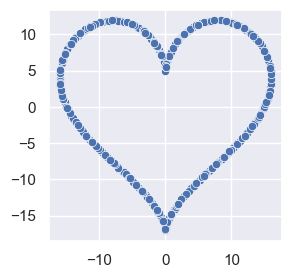

In [ ]:
# Set plotting style for nicer visualizations
sns.set(rc={"figure.figsize": (3, 3)})

# Create training data (heart-shaped curve)
TRAIN_DATA_COUNT = 1024

# By sampling theta randomly, we're creating training data that is i.i.d.
# Random angles used to sample random points from the heart curve rather than equally spaced points
theta = np.random.uniform(0, 2 * np.pi, TRAIN_DATA_COUNT)

# Parametric equations for a heart curve
x = 16 * (np.sin(theta) ** 3)
y = (
    13 * np.cos(theta)
    - 5 * np.cos(2 * theta)
    - 2 * np.cos(3 * theta)
    - np.cos(4 * theta)
)

# Visualize the dataset
sns.scatterplot(x=x, y=y)

In [17]:
# Convert to torch tensors
train_data = torch.tensor(np.stack((x, y), axis=1), dtype=torch.float32)

# Dummy labels (not used in GAN training) but included here so we can use the DataLoader
train_labels = torch.zeros(TRAIN_DATA_COUNT)

# Wrap into dataset format expected by DataLoader
train_set = list(zip(train_data, train_labels))

# DataLoader shuffles and creates mini-batches
BATCH_SIZE = 64
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)

In [18]:
"""
In a GAN, the two networks play different roles so they have different defintions and are not mirrors of one another.

Discriminator:
 - Task: classify input samples as real (from the dataset) or fake (from the generator)
 - Needs to be a strong critic with enough capacity to capture details of the data distribution
 - That means more layers, more neurons, and regularization via dropout
 - Binary classifier with a high sensitivity

Generator:
 - Task: transform random noise (latent space) into realistic looking samples
 - Starts from low dim noise (2D here)
 - Needs only a few layers to gradually expand this noise into the 2D space of real data points (x,y)
 - Data creator that just needs aneough flexibility to approximate real distribution
"""
discriminator = nn.Sequential(
    nn.Linear(2, 256),   # input: 2D point (x,y), output: 256 hidden units
    nn.ReLU(),
    nn.Dropout(0.3),     # dropout helps prevent overfitting
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64, 1),    # output: 1 value (probability)
    nn.Sigmoid(),        # squashes output into range [0, 1]
)

generator = nn.Sequential(
    nn.Linear(2, 16),    # input: 2D random noise vector
    nn.ReLU(),
    nn.Linear(16, 32),
    nn.ReLU(),
    nn.Linear(32, 2),    # output: 2D point (x,y)
)

Epoch 200 | D Loss: 0.5795 | G Loss: 1.3821


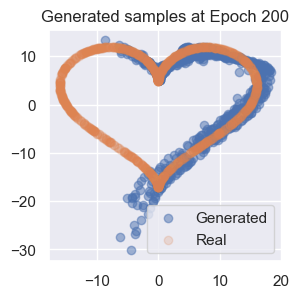

Epoch 400 | D Loss: 0.5129 | G Loss: 1.0620


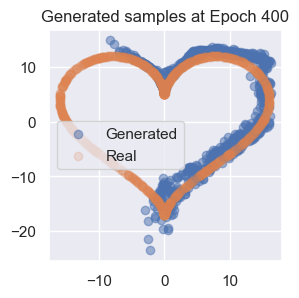

Epoch 600 | D Loss: 0.5243 | G Loss: 1.1042


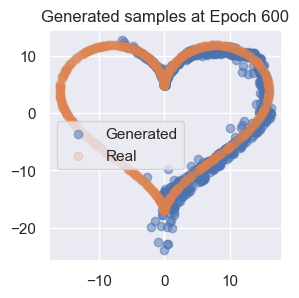

Epoch 800 | D Loss: 0.5153 | G Loss: 1.1681


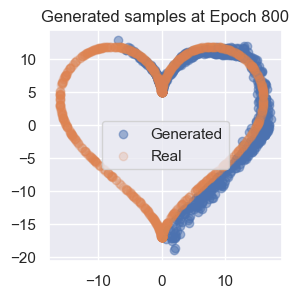

Epoch 1000 | D Loss: 0.4753 | G Loss: 1.0446


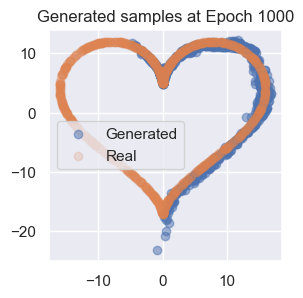

Epoch 1200 | D Loss: 0.5265 | G Loss: 1.0622


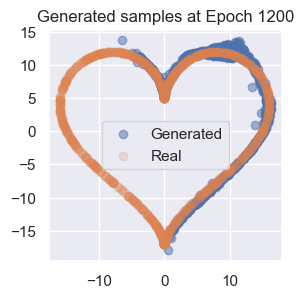

Epoch 1400 | D Loss: 0.5271 | G Loss: 1.1214


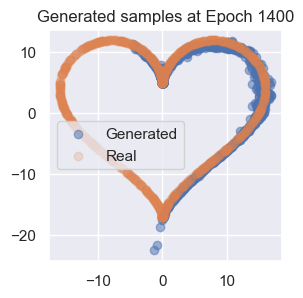

Epoch 1600 | D Loss: 0.5061 | G Loss: 1.2028


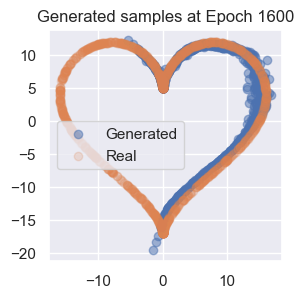

Epoch 1800 | D Loss: 0.6124 | G Loss: 1.0865


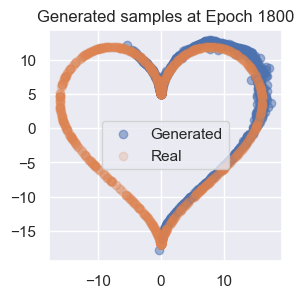

Epoch 2000 | D Loss: 0.4724 | G Loss: 1.0227


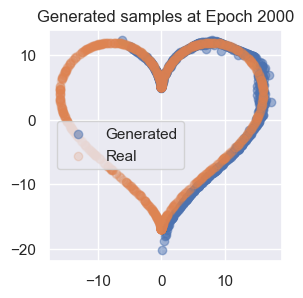

In [23]:
# Training setup
LR = 0.001
NUM_EPOCHS = 2000
loss_fn = nn.BCELoss()  # Binary cross-entropy (used for yes/no classification)

# Optimizers for both networks
optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=LR)
optimizer_g = torch.optim.Adam(generator.parameters(), lr=LR)

# Training loop
for epoch in range(1, NUM_EPOCHS + 1):

    # Train via minibatches rather than alternating
    for real_samples, _ in train_loader:
        batch_size = real_samples.size(0)  # current batch size

        # Train Discriminator
        real_labels = torch.ones((batch_size, 1))   # label = 1 for real data
        fake_labels = torch.zeros((batch_size, 1))  # label = 0 for fake data

        # Generate fake samples from random noise
        latent_samples = torch.randn((batch_size, 2))  # 2D noise vector
        fake_samples = generator(latent_samples).detach()  
        # .detach() stops gradient flow into generator when training D

        # Combine real and fake samples
        all_samples = torch.cat((real_samples, fake_samples))
        all_labels = torch.cat((real_labels, fake_labels))

        # Forward pass through discriminator
        optimizer_d.zero_grad()
        predictions = discriminator(all_samples)
        loss_d = loss_fn(predictions, all_labels)  # how well D classifies
        loss_d.backward()
        optimizer_d.step()

        # Train Generator
        latent_samples = torch.randn((batch_size, 2))  # fresh random noise
        optimizer_g.zero_grad()
        generated = generator(latent_samples)  # generate fake points
        predictions_fake = discriminator(generated)  # discriminator output
        loss_g = loss_fn(predictions_fake, real_labels)  
        # Trick D: generator wants fake data to be classified as real (label=1)

        loss_g.backward()
        optimizer_g.step()

    # Progress logging & visualization
    if epoch % 200 == 0:
        print(f"Epoch {epoch} | D Loss: {loss_d.item():.4f} | G Loss: {loss_g.item():.4f}")
        with torch.no_grad():
            latent_space_samples = torch.randn(1000, 2)
            generated_samples = generator(latent_space_samples).detach()
        plt.figure()
        plt.scatter(generated_samples[:, 0], generated_samples[:, 1], alpha=0.5, label="Generated")
        plt.scatter(x, y, alpha=0.2, label="Real")
        plt.legend()
        plt.title(f"Generated samples at Epoch {epoch}")
        plt.show()


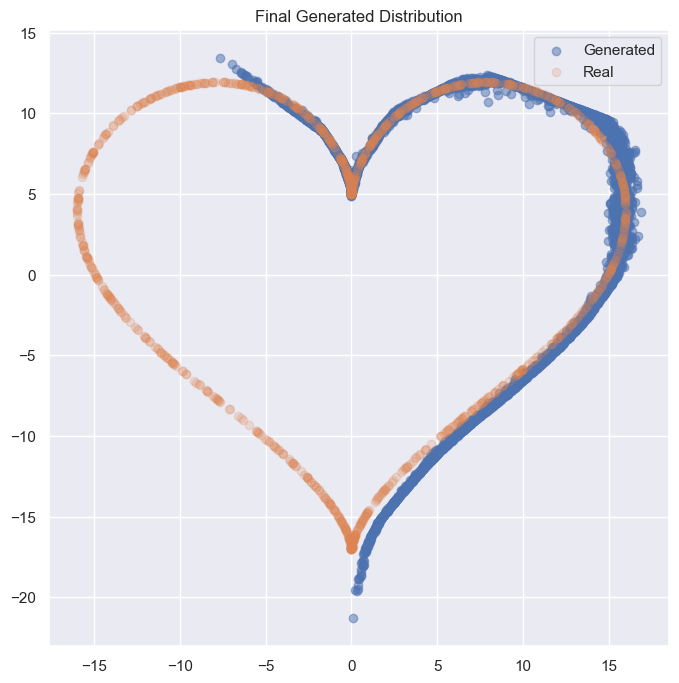

In [24]:
# Final visualization of trained generator
latent_space_samples = torch.randn(5000, 2)
generated_samples = generator(latent_space_samples).detach()

plt.figure(figsize=(8, 8))
plt.scatter(generated_samples[:, 0], generated_samples[:, 1], alpha=0.5, label="Generated")
plt.scatter(x, y, alpha=0.2, label="Real")
plt.legend()
plt.title("Final Generated Distribution")
plt.show()